# Milan mobile traffic forecasting: full pipeline

Runs the whole project on the real Telecom Italia data, in the same order as `run_all.sh`: ingestion, EDA, time-series analysis, baselines, tuning rounds, final test runs, comparison and the report tables.

I use this because my laptop cannot hold the 20.8 GB of raw files. Kaggle gives about 30 GB of RAM and a free GPU for the LSTM rounds.

On Kaggle, add a dataset with the 62 `sms-call-internet-mi-YYYY-MM-DD.txt` files (Add data > search "Telecom Italia" or "sms-call-internet-mi"). The next cell searches `/kaggle/input` for those filenames, so the folder name does not matter. Check you have all 62 days first, because several public copies only cover the first week. If you want the LSTM rounds to go faster, turn on a GPU under Settings > Accelerator.

On Colab, download the files once from https://doi.org/10.7910/DVN/EGZHFV (there is a guestbook to fill in) into Drive, mount it, and point `RAW_DIR` at that folder.

In [1]:
import os
import sys
import subprocess
import pathlib
import zipfile
import shutil

ON_KAGGLE = os.path.exists("/kaggle")
ON_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if ON_KAGGLE:
    input_dir = pathlib.Path("/kaggle/input")

    # some attached datasets come unpacked, others as one big zip, so handle both
    txt_files = sorted(input_dir.rglob("sms-call-internet-mi-*.txt"))

    if txt_files:
        RAW_DIR = str(txt_files[0].parent)
        print(f"Found {len(txt_files)} traffic files in {RAW_DIR}")

    else:
        zip_files = sorted(input_dir.rglob("*.zip"))

        if not zip_files:
            raise FileNotFoundError(
                "No traffic files or ZIP found. Attach your private Kaggle dataset first."
            )

        zip_path = zip_files[0]
        output_dir = pathlib.Path("/kaggle/working/milan_raw")

        total, used, free = shutil.disk_usage("/kaggle/working")
        print(f"Free working space: {free / 1024**3:.1f} GB")
        print("ZIP selected:", zip_path)

        if output_dir.exists():
            print("Using existing extraction:", output_dir)
        else:
            output_dir.mkdir(parents=True, exist_ok=True)
            print("Extracting the dataset. This may take several minutes...")

            with zipfile.ZipFile(zip_path) as archive:
                archive.extractall(output_dir)

        txt_files = sorted(output_dir.rglob("sms-call-internet-mi-*.txt"))

        if len(txt_files) != 62:
            raise RuntimeError(
                f"Expected 62 traffic files after extraction, but found {len(txt_files)}."
            )

        RAW_DIR = str(txt_files[0].parent)
        print(f"Extracted {len(txt_files)} traffic files into {RAW_DIR}")

    WORK = "/kaggle/working"

elif ON_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    RAW_DIR = "/content/drive/MyDrive/milan_raw"
    WORK = "/content"

else:
    RAW_DIR = "data/raw"
    WORK = "."

print("RAW_DIR:", RAW_DIR)

Found 62 traffic files in /kaggle/input/datasets/samuelihimbazwe/telecom-italia-milan-full/sms-call-internet-mi-
RAW_DIR: /kaggle/input/datasets/samuelihimbazwe/telecom-italia-milan-full/sms-call-internet-mi-


In [ ]:
import os, sys, subprocess, pathlib

ON_KAGGLE = os.path.exists("/kaggle")
ON_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

def find_raw_dir(root):
    """Return the folder that actually contains sms-call-internet-mi-*.txt files."""
    root = pathlib.Path(root)
    hits = sorted(root.rglob("sms-call-internet-mi-*.txt"))
    if not hits:
        print("nothing matching sms-call-internet-mi-YYYY-MM-DD.txt under", root)
        if root.exists():
            print("what is there:")
            for p in sorted(root.rglob("*"))[:40]:
                print(" ", p)
        return str(root)
    raw_dir = str(hits[0].parent)
    print(f"found {len(hits)} daily files in {raw_dir}")
    return raw_dir

if ON_KAGGLE:
    
    RAW_DIR = find_raw_dir("/kaggle/input")
    WORK = "/kaggle/working"
elif ON_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    RAW_DIR = find_raw_dir("/content/drive/MyDrive/milan_raw")
    WORK = "/content"
else:
    RAW_DIR = find_raw_dir("data/raw")
    WORK = "."
print("platform:", "kaggle" if ON_KAGGLE else "colab" if ON_COLAB else "local", "| raw dir:", RAW_DIR)

found 62 daily files in /kaggle/input/datasets/samuelihimbazwe/telecom-italia-milan-full/sms-call-internet-mi-
platform: kaggle | raw dir: /kaggle/input/datasets/samuelihimbazwe/telecom-italia-milan-full/sms-call-internet-mi-


In [3]:
%cd {WORK}
if not pathlib.Path("Time-Series-Forecasting").exists():
    !git clone -q https://github.com/Samkwizera/Time-Series-Forecasting.git
%cd Time-Series-Forecasting
!pip install -q -r requirements.txt
!pip install -q -e .

/kaggle/working
/kaggle/working/Time-Series-Forecasting
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for milan-forecast (pyproject.toml) ... done


The default config looks for the raw files in `data/raw`, which is not where Kaggle puts them. So I copy the config and swap in `RAW_DIR`. Every other path stays relative, so the Parquet intermediates land in the writable working directory.

The next cell counts the 62 daily files locally. It does not call Harvard Dataverse, because that API keeps returning 403 from Kaggle.

In [4]:
import yaml
cfg = yaml.safe_load(open("config/default.yaml"))
cfg["paths"]["raw_dir"] = RAW_DIR
yaml.safe_dump(cfg, open("config/kaggle.yaml", "w"), sort_keys=False)
os.environ["MILAN_CONFIG"] = "config/kaggle.yaml"

def run(script, *args):
    """Run a pipeline script and stop the notebook if it fails."""
    cmd = [sys.executable, script, "--config", "config/kaggle.yaml", *args]
    print(">", " ".join(cmd))
    subprocess.run(cmd, check=True)

run("scripts/00_download.py", "--verify")

> /usr/bin/python3 scripts/00_download.py --config config/kaggle.yaml --verify
62 expected daily files (filename check only; Dataverse sizes not cached)
found 62 sms-call-internet-mi-*.txt files under /kaggle/input/datasets/samuelihimbazwe/telecom-italia-milan-full/sms-call-internet-mi-
all files present and verified


## Stage 1: ingestion

This is the slow part. On the full 20.8 GB it takes about an hour. Wait until it prints the `hourly_*.parquet` paths.

Nothing below works without it. Skip it or stop it early and EDA will go looking for `data/processed/citywide_10min.parquet` and fail.

In [5]:
run("scripts/01_ingest.py")
from pathlib import Path
import pandas as pd
city = Path("data/processed/citywide_10min.parquet")
assert city.exists(), (
    f"ingest did not write {city}. Scroll up: either the raw files were missing "
    "or the ingest cell was interrupted. Re-run this cell and wait for it to finish."
)
pd.read_csv("reports/tables/memory_log.csv").tail(8)

> /usr/bin/python3 scripts/01_ingest.py --config config/kaggle.yaml


2026-09-12 19:14:23,271 INFO naive pandas load of sms-call-internet-mi-2013-11-01.txt would need ~275 MB for ~4.5M rows
2026-09-12 19:14:28,787 INFO ingest:2013-11-01: 5.5s, RSS start 108 MB, peak 840 MB
2026-09-12 19:14:28,789 INFO 2013-11-01 -> 1439982 rows, 41.2 MB in memory, 27.8 MB on disk
2026-09-12 19:14:33,330 INFO ingest:2013-11-02: 4.5s, RSS start 840 MB, peak 1027 MB
2026-09-12 19:14:33,332 INFO 2013-11-02 -> 1439986 rows, 41.2 MB in memory, 27.2 MB on disk
2026-09-12 19:14:37,813 INFO ingest:2013-11-03: 4.5s, RSS start 1027 MB, peak 1100 MB
2026-09-12 19:14:37,815 INFO 2013-11-03 -> 1439963 rows, 41.2 MB in memory, 27.3 MB on disk
2026-09-12 19:14:42,806 INFO ingest:2013-11-04: 5.0s, RSS start 1100 MB, peak 1170 MB
2026-09-12 19:14:42,808 INFO 2013-11-04 -> 1439976 rows, 41.2 MB in memory, 27.5 MB on disk
2026-09-12 19:14:47,865 INFO ingest:2013-11-05: 5.1s, RSS start 1170 MB, peak 1217 MB
2026-09-12 19:14:47,867 INFO 2013-11-05 -> 1439977 rows, 41.2 MB in memory, 27.5 MB o

,stage,seconds,rss_start_mb,rss_peak_mb,rss_end_mb,note
60,ingest:2013-12-31,4.66,1415.5,1432.0,1432.0,309 MB raw
61,ingest:2014-01-01,4.66,1432.0,1458.4,1458.4,314 MB raw
62,wide_hourly:sms_in,17.62,1387.0,1469.0,1469.0,NaN
63,wide_hourly:sms_out,17.20,1469.0,1511.2,1511.2,NaN
64,wide_hourly:call_in,17.49,1511.2,1511.2,1511.2,NaN
65,wide_hourly:call_out,17.66,1511.2,1511.5,1511.5,NaN
66,wide_hourly:internet,17.51,1511.5,1514.1,1514.1,NaN
67,citywide_10min,9.53,1514.1,5244.4,5242.4,NaN


## Stages 2-3: exploratory and time-series analysis

EDA makes the citywide plots, the spatial maps, and the k-means clustering that picks which cells we forecast (`selected_cells.json`). TSA then runs the stationarity tests, STL/MSTL and ACF/PACF on those cells.

I only show a few figures here. The rest are in `reports/figures/`.

> /usr/bin/python3 scripts/02_eda.py --config config/kaggle.yaml


2026-09-12 19:21:13,501 INFO selected cells: {'duomo': 5060, 'bocconi': 4259, 'navigli': 4456, 'business': 4855, 'business-2': 5161, 'mixed_suburban': 5857, 'mixed_suburban-2': 4755}
2026-09-12 19:21:15,565 INFO eda: 10.9s, RSS start 245 MB, peak 567 MB
2026-09-12 19:21:15,567 INFO summary statistics:
                             total  share_pct
sms_in                4.053154e+08   6.001105
sms_out               2.198796e+08   3.255540
call_in               2.676241e+08   3.962445
call_out              3.082995e+08   4.564686
internet              5.552894e+09  82.216225
cells_nonzero_target  1.000000e+04        NaN
cell_mean_cv          3.609249e-01        NaN
n_hours               1.488000e+03        NaN
n_missing_hours       0.000000e+00        NaN
2026-09-12 19:21:15,567 INFO figures written to /kaggle/working/Time-Series-Forecasting/reports/figures


> /usr/bin/python3 scripts/03_tsa.py --config config/kaggle.yaml


2026-09-12 19:22:14,633 INFO stationarity table:
          series                        transform  adf_stat  adf_p  kpss_stat  kpss_p        verdict
        citywide                              raw    -2.137  0.230      3.631   0.010 non-stationary
        citywide                            log1p    -1.257  0.649      3.704   0.010 non-stationary
        citywide                    log1p, diff 1   -11.909  0.000      0.004   0.100     stationary
        citywide          log1p, seasonal diff 24    -5.584  0.000      0.222   0.100     stationary
        citywide log1p, diff 1 + seasonal diff 24    -9.818  0.000      0.010   0.100     stationary
           duomo                              raw    -3.670  0.005      0.584   0.024   inconclusive
           duomo                            log1p    -3.389  0.011      1.023   0.010   inconclusive
           duomo                    log1p, diff 1   -13.194  0.000      0.007   0.100     stationary
           duomo          log1p, seasonal 

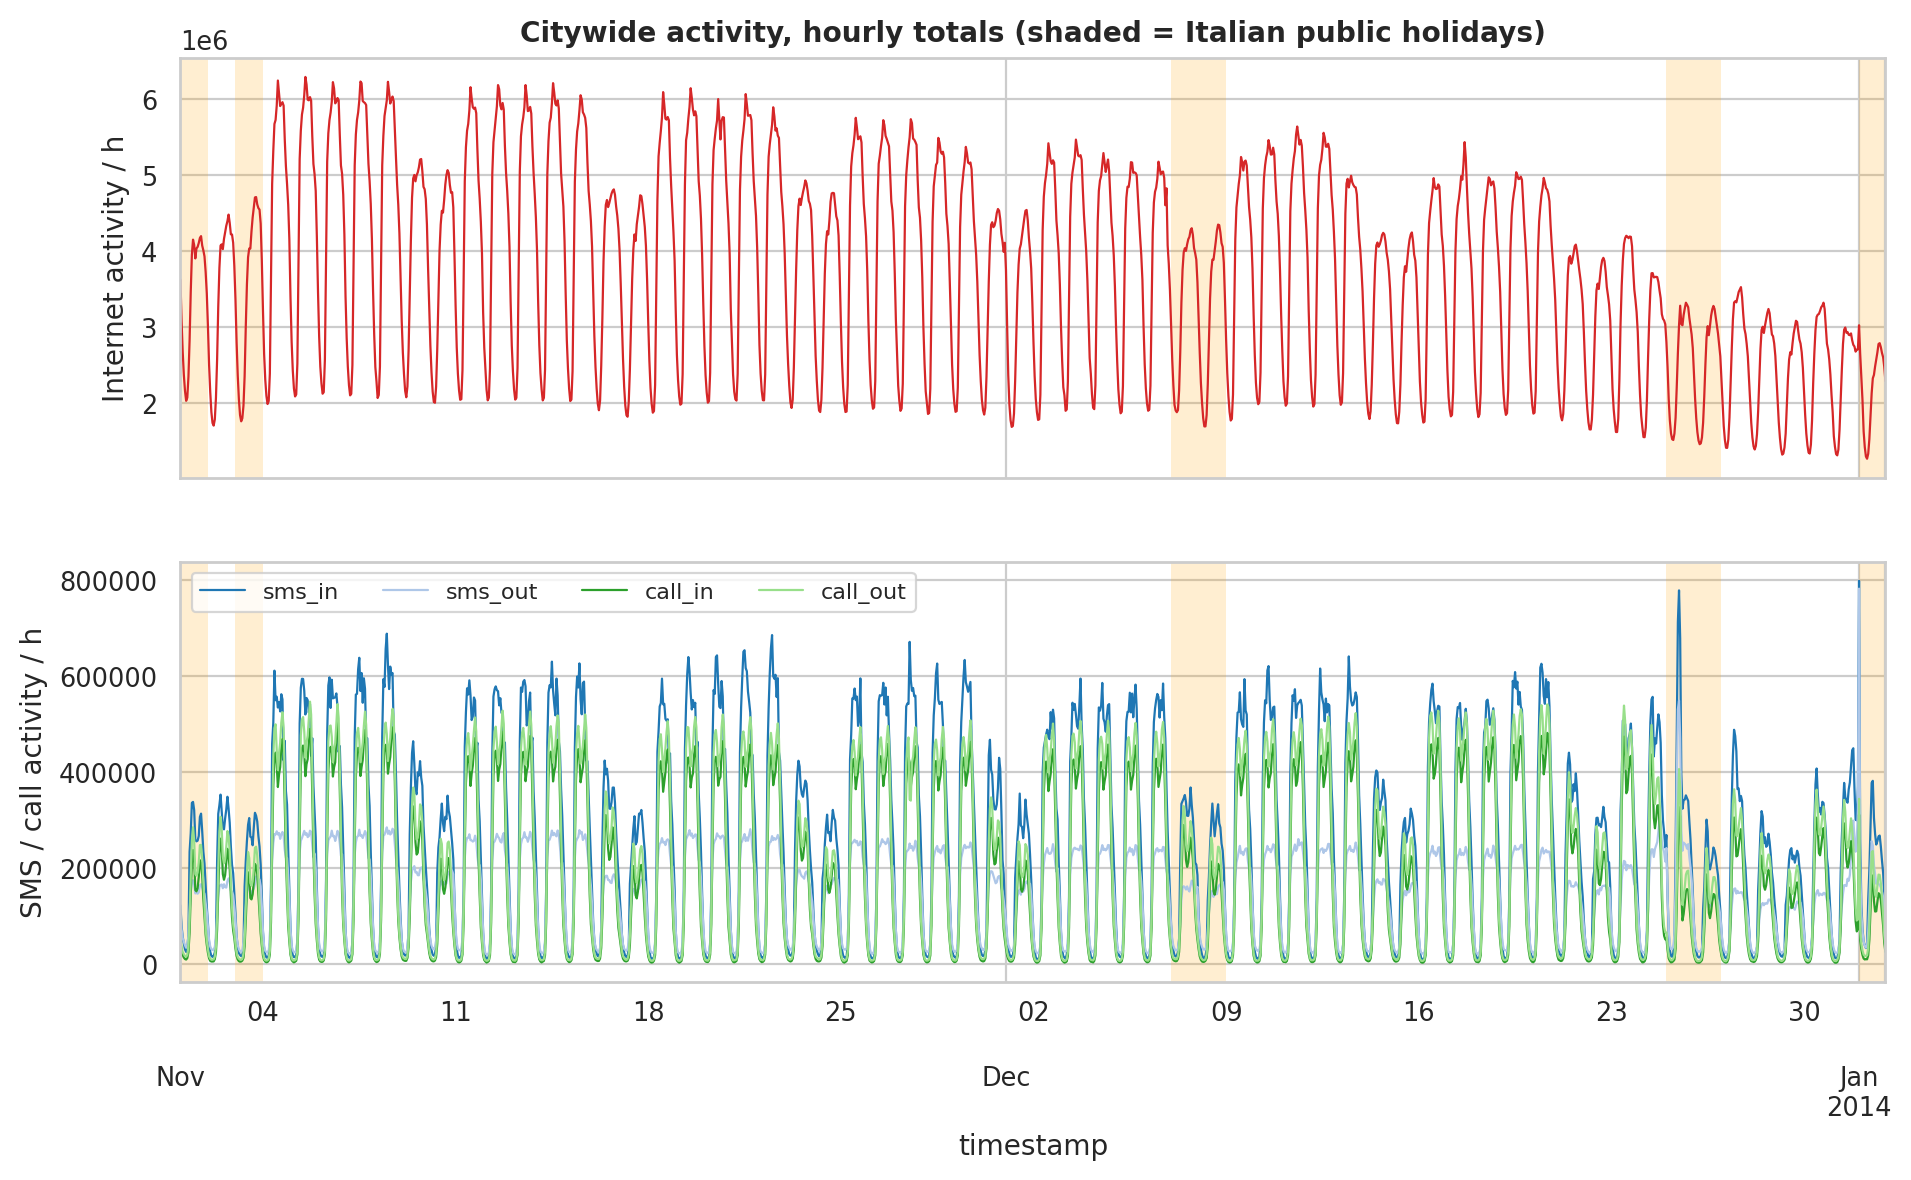

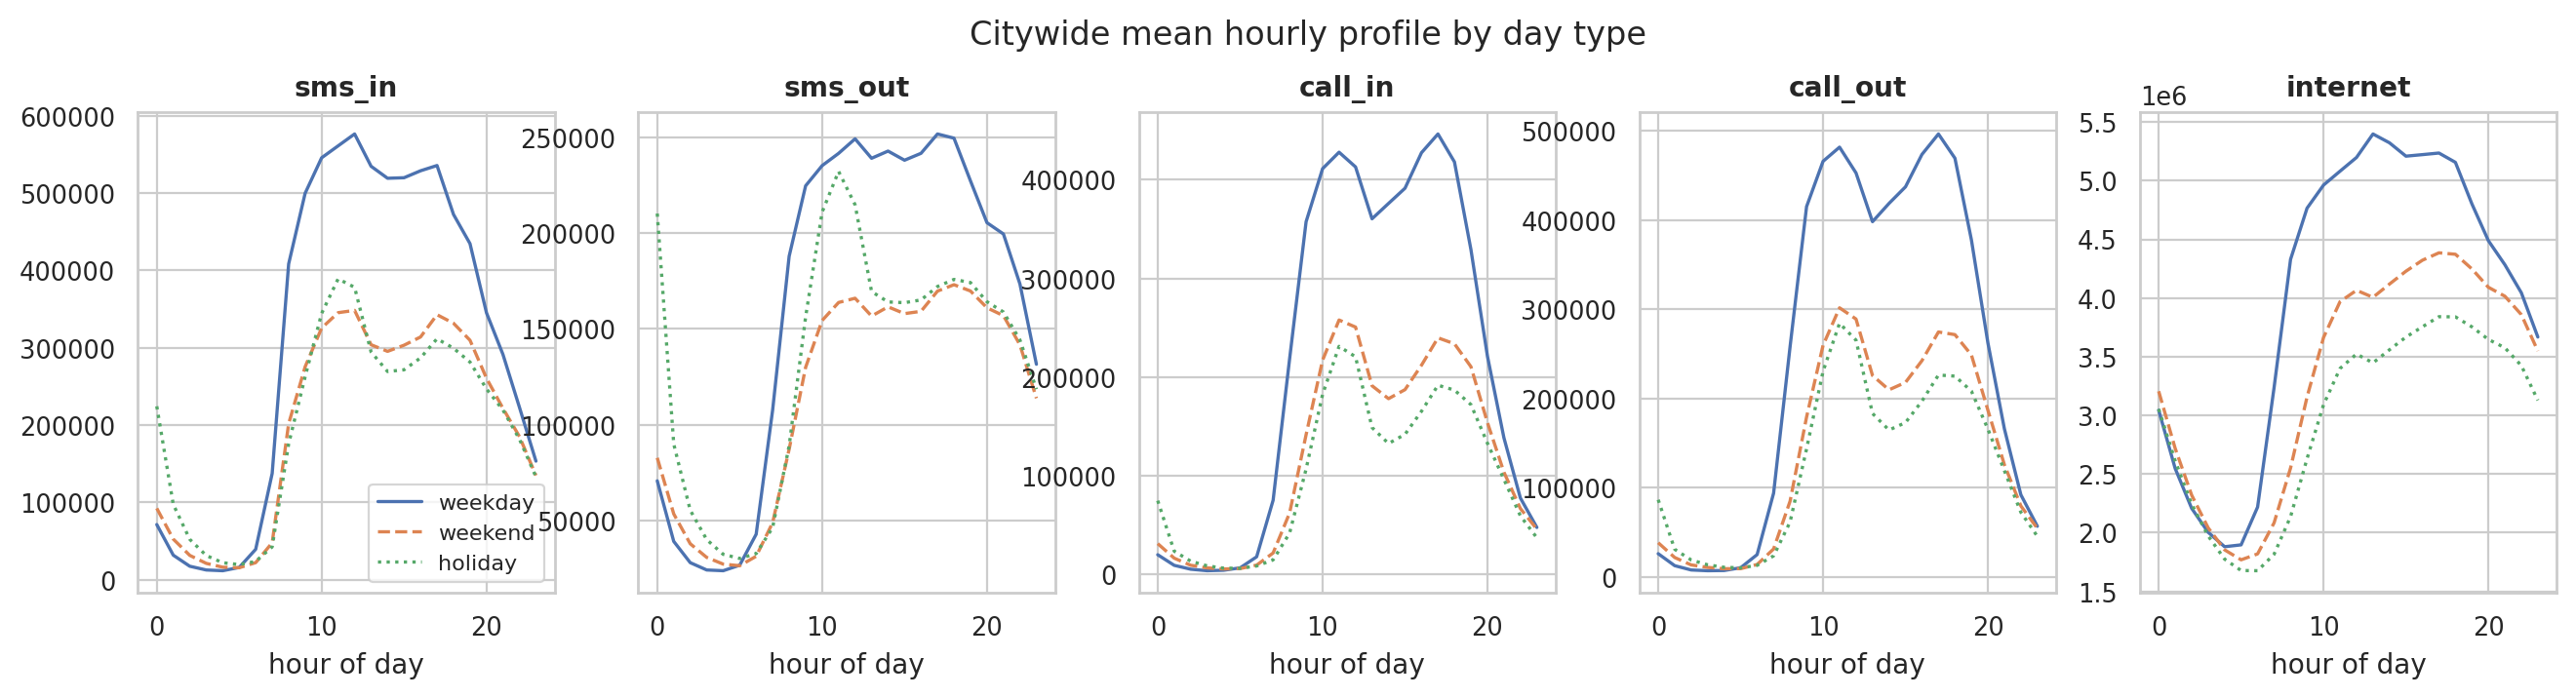

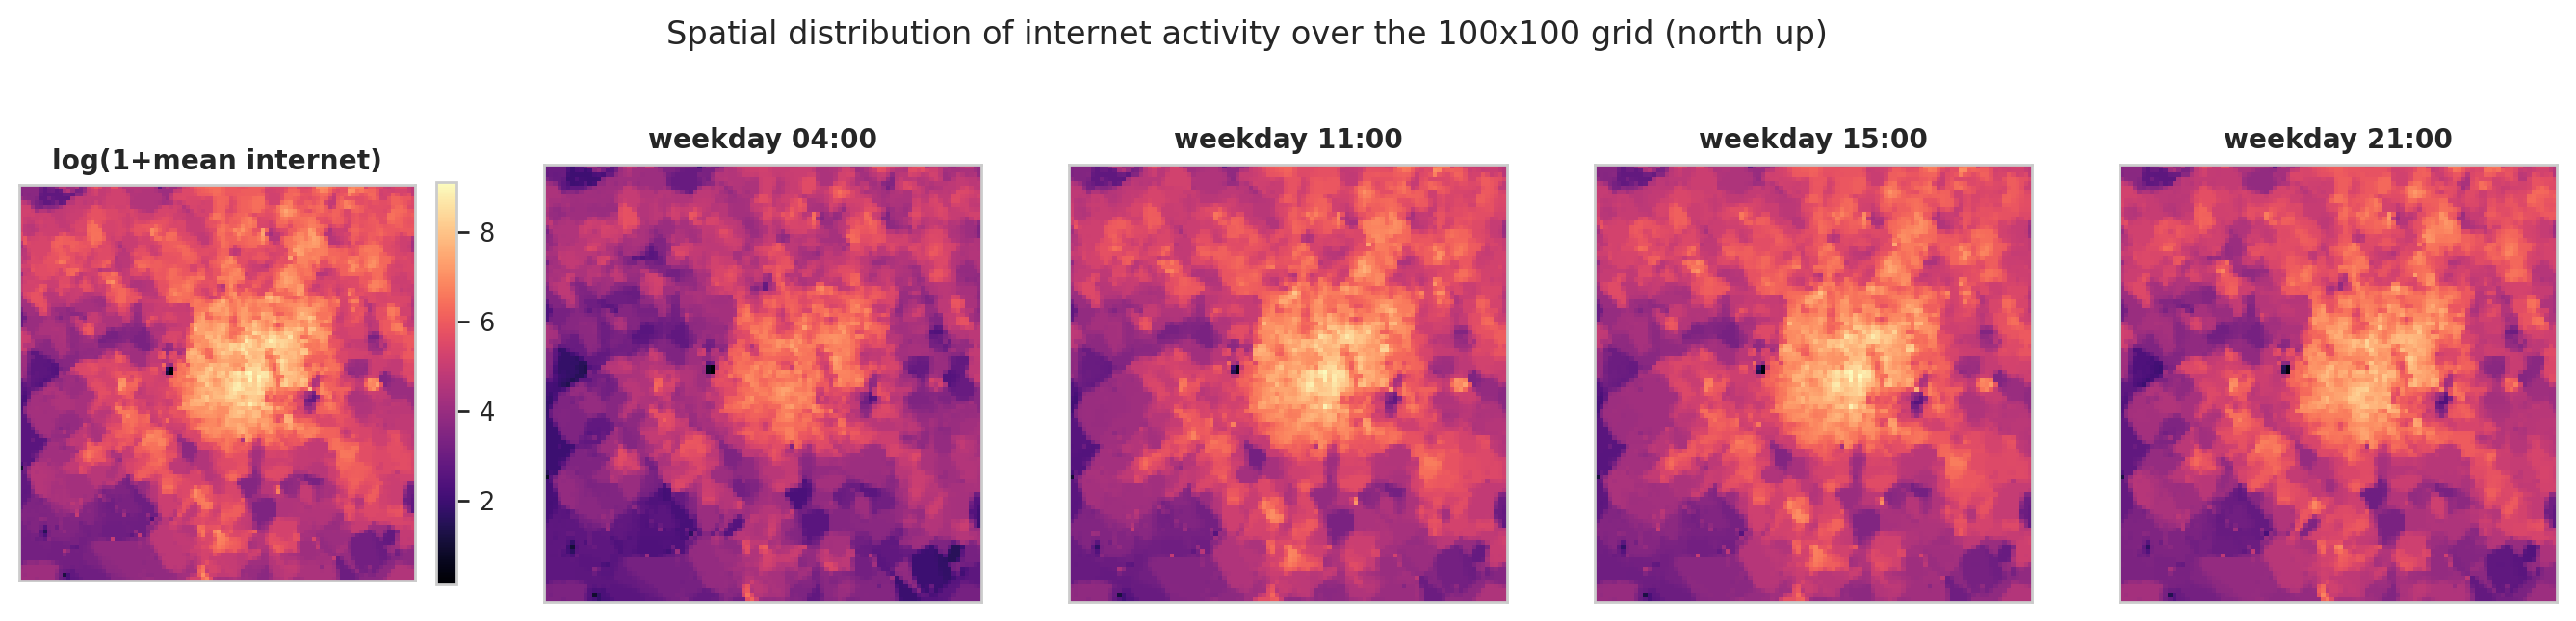

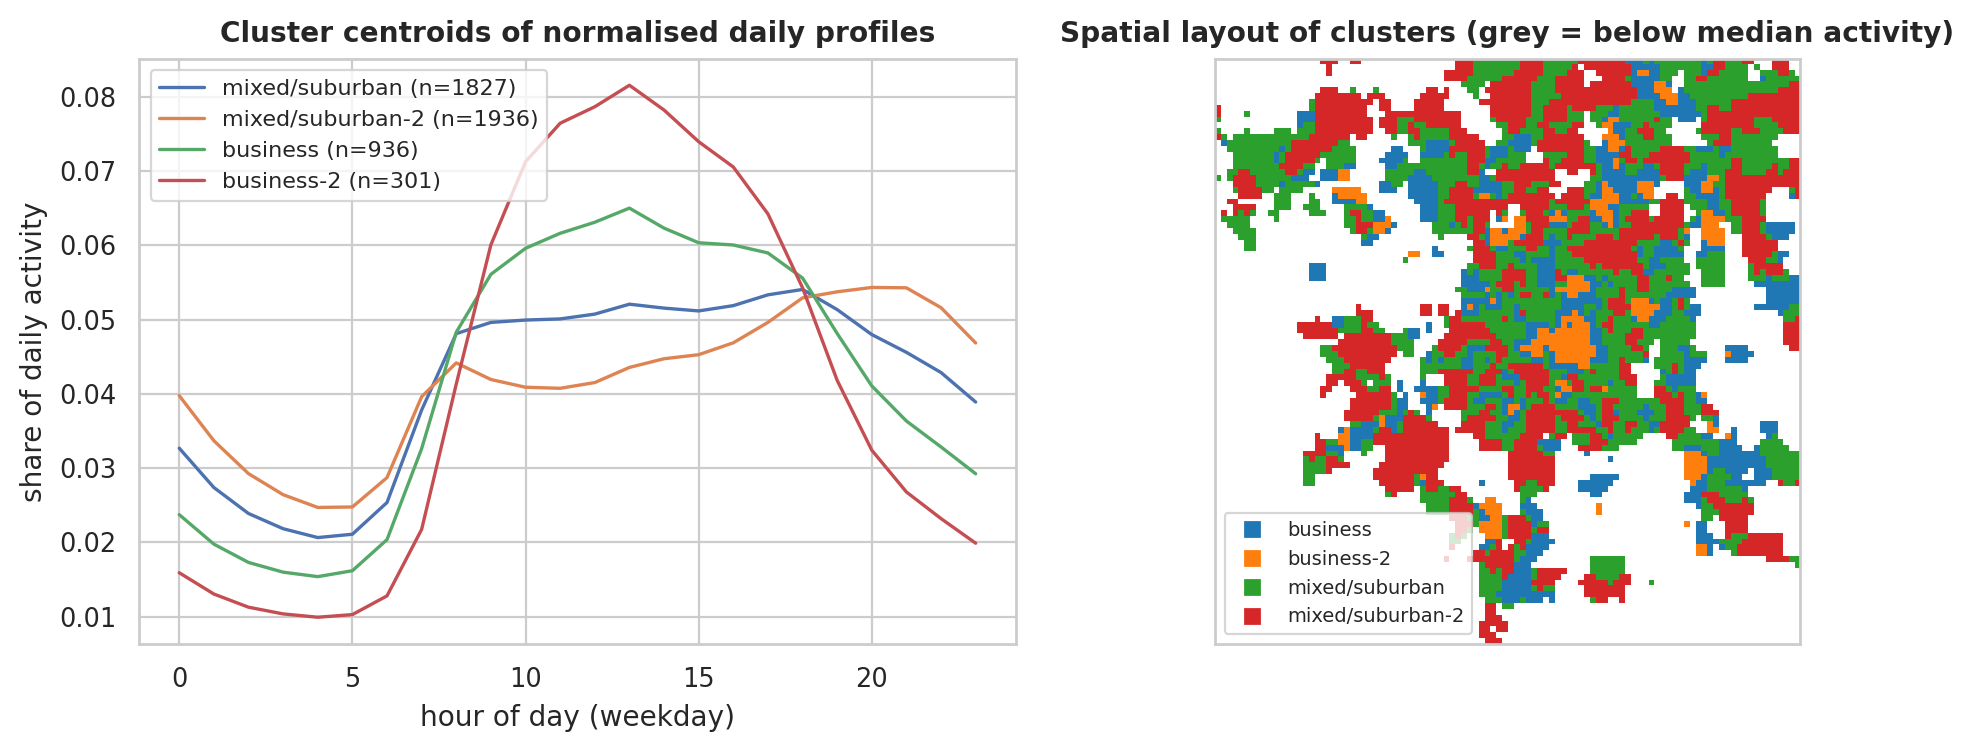

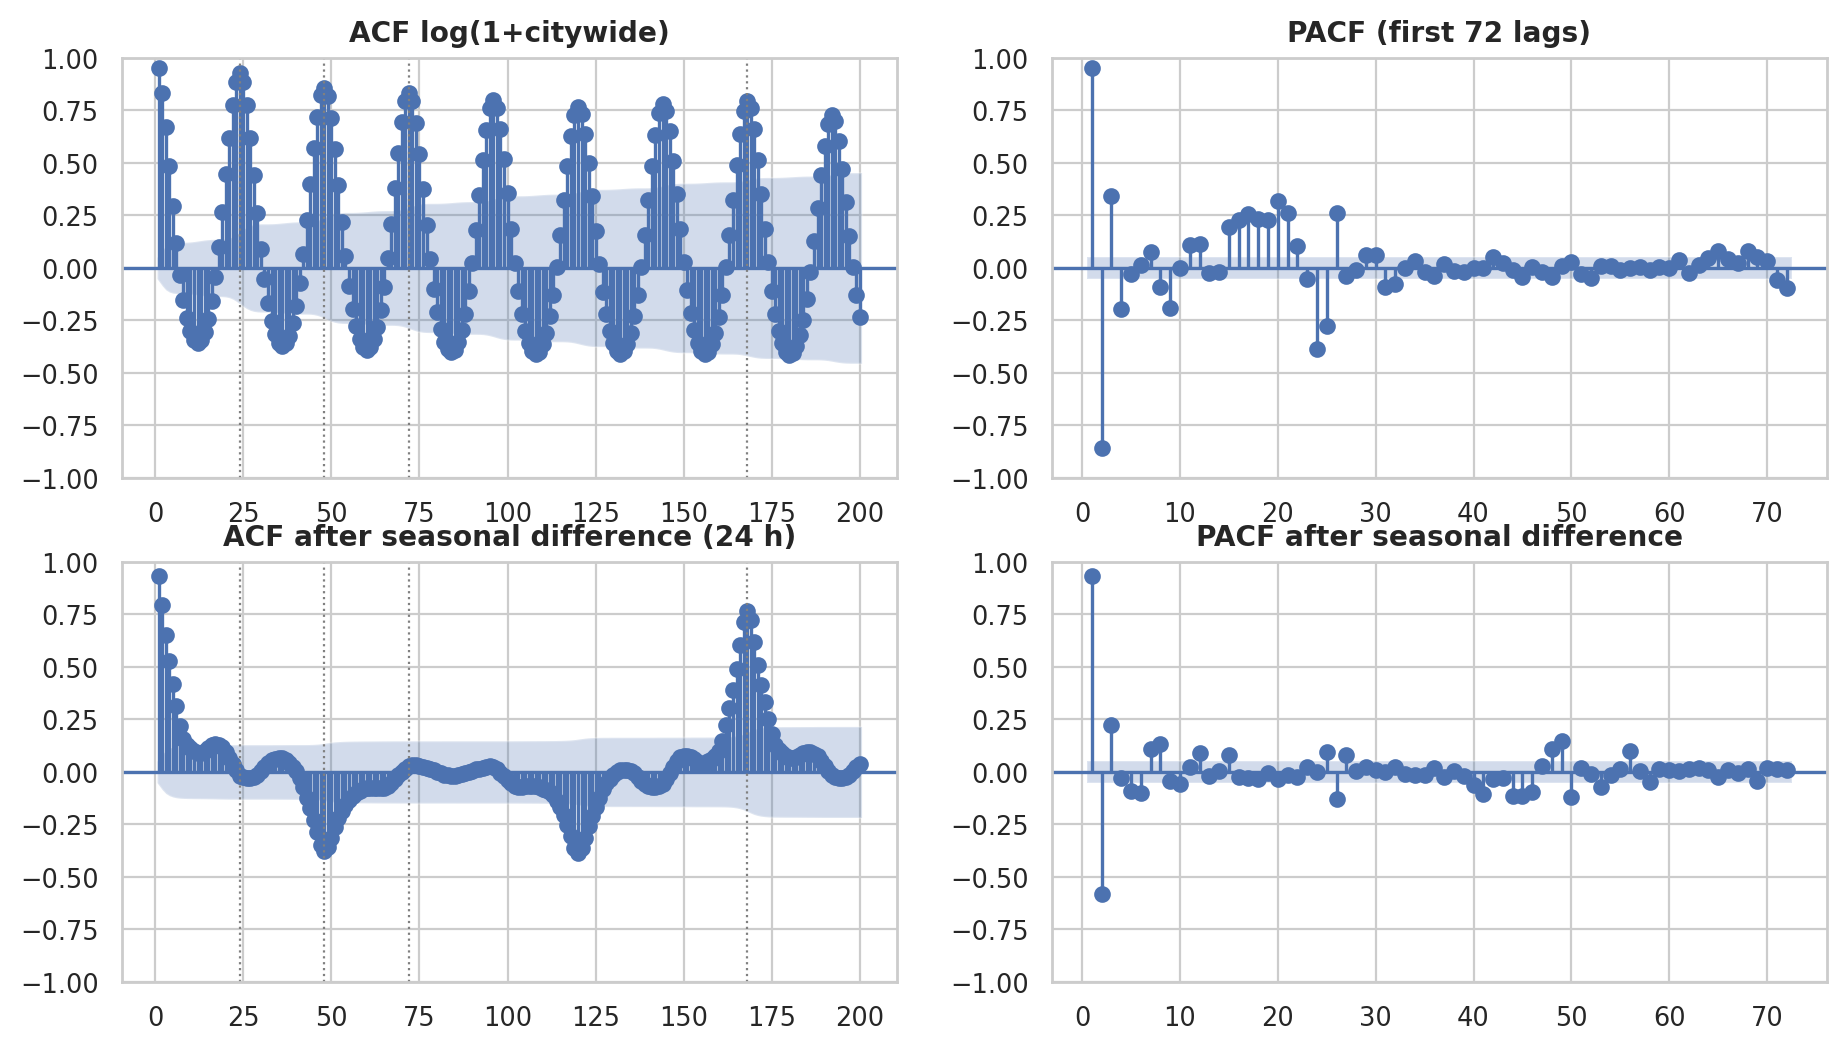

In [6]:
run("scripts/02_eda.py")
run("scripts/03_tsa.py")
from IPython.display import Image, display
for f in ["eda_citywide_hourly", "eda_daily_profiles", "eda_spatial_internet", "eda_clusters_internet", "tsa_acf_citywide"]:
    display(Image(f"reports/figures/{f}.png", width=900))

## Stages 4-5: baselines and tuning rounds

The three naive baselines run first, on both splits, so every later number has something to be compared against.

Each tuning round lives in `experiments/tuning_plan.yaml` with a `why` field I fill in before running it, based on what the last round or the ACF suggested. Every run appends a row to `experiments/experiment_log.md`, so the log is the actual trail of what I tried and not a summary I wrote at the end.

SARIMA and LSTM rounds are manual. For LightGBM the manual rounds ablate the feature groups first, then 20 Optuna trials handle the capacity parameters, where I had no strong prior. If a result suggests something new, add a round to the YAML and rerun `05_tune.py --rounds <id>`.

In [7]:
run("scripts/04_train.py", "--model", "baselines", "--part", "val")
run("scripts/04_train.py", "--model", "baselines", "--part", "test")
run("scripts/05_tune.py", "--model", "sarima")
run("scripts/05_tune.py", "--model", "lightgbm", "--optuna", "20")
run("scripts/05_tune.py", "--model", "lstm")
print(open("experiments/experiment_log.md").read())

> /usr/bin/python3 scripts/04_train.py --config config/kaggle.yaml --model baselines --part val


2026-09-12 19:22:27,082 INFO train:baselines:default:val: 0.1s, RSS start 1056 MB, peak 1056 MB
2026-09-12 19:22:27,101 INFO baselines metrics on val:
         model           series  horizon   n      mae      rmse   smape  mase
         naive          bocconi        1 145  167.137   233.444  12.055 0.314
         naive          bocconi        6 145  809.585   989.922  56.355 1.522
         naive          bocconi       24 145  304.331   537.049  20.064 0.572
         naive         business        1 145  590.335   848.817  10.793 0.575
         naive         business        6 145 2895.524  3436.832  50.613 2.818
         naive         business       24 145  895.708  1418.887  14.790 0.872
         naive       business-2        1 145 1778.561  2461.856  25.432 1.000
         naive       business-2        6 145 9152.494 11338.997 109.268 5.146
         naive       business-2       24 145 2142.023  3873.384  22.032 1.204
         naive            duomo        1 145  648.242   814.208  19.1

> /usr/bin/python3 scripts/04_train.py --config config/kaggle.yaml --model baselines --part test


2026-09-12 19:22:36,046 INFO train:baselines:default:test: 0.1s, RSS start 1048 MB, peak 1048 MB
2026-09-12 19:22:36,064 INFO baselines metrics on test:
         model           series  horizon   n      mae      rmse   smape  mase
         naive          bocconi        1 241   48.965    71.603   8.646 0.092
         naive          bocconi        6 241  172.736   222.104  31.287 0.325
         naive          bocconi       24 241  135.508   181.105  22.921 0.255
         naive         business        1 241  210.947   273.338   8.012 0.205
         naive         business        6 241  852.217  1046.102  32.664 0.829
         naive         business       24 241  438.137   589.341  15.966 0.426
         naive       business-2        1 241 1485.493  2374.952  27.839 0.835
         naive       business-2        6 241 7462.962 10339.039 113.440 4.196
         naive       business-2       24 241 2604.745  4350.446  44.786 1.464
         naive            duomo        1 241  472.854   710.291  18

> /usr/bin/python3 scripts/05_tune.py --config config/kaggle.yaml --model sarima


...

2026-09-12 19:35:13,446 INFO lightgbm h=1: 750 trees, holdout l1 0.1330, 7056 rows
2026-09-12 19:35:15,879 INFO lightgbm h=6: 541 trees, holdout l1 0.2328, 7056 rows
2026-09-12 19:35:17,597 INFO lightgbm h=24: 376 trees, holdout l1 0.2308, 7056 rows
2026-09-12 19:35:17,618 INFO train:lightgbm:g1:val: 7.3s, RSS start 1051 MB, peak 1060 MB
2026-09-12 19:35:17,628 INFO lightgbm metrics on val:
   model           series  horizon   n      mae     rmse  smape  mase
lightgbm          bocconi        1 145   96.059  132.658  6.380 0.181
lightgbm          bocconi        6 145  238.895  354.015 14.528 0.449
lightgbm          bocconi       24 145  310.560  480.073 17.806 0.584
lightgbm         business        1 145  269.231  368.453  4.407 0.262
lightgbm         business        6 145  419.170  554.793  6.867 0.408
lightgbm         business       24 145  551.078  779.632  8.894 0.536
lightgbm       business-2        1 145  665.317 1038.408  8.564 0.374
lightgbm       business-2        6 145 1436.43

> /usr/bin/python3 scripts/05_tune.py --config config/kaggle.yaml --model lstm


2026-09-12 19:43:23,119 INFO lstm: 7135 params, 59 epochs, best holdout l1 0.1680
2026-09-12 19:43:23,150 INFO train:lstm:l1:val: 12.2s, RSS start 1052 MB, peak 1667 MB
2026-09-12 19:43:23,160 INFO lstm metrics on val:
model           series  horizon   n      mae     rmse  smape  mase
 lstm          bocconi        1 145  206.687  306.415 10.539 0.389
 lstm          bocconi        6 145  570.290  753.798 26.270 1.072
 lstm          bocconi       24 145  450.908  600.474 21.781 0.848
 lstm         business        1 145  304.835  420.323  4.594 0.297
 lstm         business        6 145  737.391  913.762 10.440 0.718
 lstm         business       24 145  608.021  788.241  9.255 0.592
 lstm       business-2        1 145  668.525 1015.880  9.661 0.376
 lstm       business-2        6 145  999.604 1544.125 15.301 0.562
 lstm       business-2       24 145 1213.949 1876.930 16.218 0.683
 lstm            duomo        1 145  294.980  497.252  7.395 0.460
 lstm            duomo        6 145  494.850

# Experiment log

One row per training run. `val_*` metrics are on the validation split; the *Reasoning / next step* column records why the following run was configured as it was.

| model | run | params | val MAE | val sMAPE | val MASE | s | reasoning / next step |
|---|---|---|---|---|---|---|---|
| sarima | s1_val | order=[1, 0, 0], seasonal_order=[0, 1, 0, 24], fourier_k=0, holiday_exog=False, maxiter=200 | 594 | 12.08 | 0.717 | 3.3 | Minimal seasonal random walk + AR(1): the simplest structure consistent with the ACF (slow decay at multiples of 24). Reference point for what the seasonal difference alone buys. |
| sarima | s2_val | order=[1, 0, 1], seasonal_order=[1, 1, 1, 24], fourier_k=0, holiday_exog=False, maxiter=200 | 507 | 10.77 | 0.659 | 44.1 | Add MA terms at lag 1 and 24: PACF after seasonal differencing shows a negative spike at 24, the classic signature of a seasonal MA(1). |
| sarima | s3_val | order=[1, 0, 1], seasonal_order=[1, 1, 1, 24], fourier_k=3, holiday_exog=Fa

2026-09-12 19:44:41,621 INFO round l6 -> val MASE 0.720
2026-09-12 19:44:41,622 INFO manual rounds: {'l1': 0.721, 'l2': 0.747, 'l3': 0.714, 'l4': 0.793, 'l5': 0.711, 'l6': 0.72} -> best l5


## Stage 6: final test runs and comparison

For each model I take the config with the lowest validation MASE and run it once on the test split, 22 Dec to 1 Jan. That window covers the holidays on purpose. The test period is not touched before this point.

`06_compare.py` then scores everything against the baselines, runs the Diebold-Mariano tests and writes the failure-analysis figures.

In [8]:
# same selection rule as run_all.sh, written out here so the chosen runs are visible in the output
import json, glob
def best(model):
    runs = [json.load(open(p)) for p in glob.glob(f"experiments/runs/{model}/*_val.json")]
    r = min(runs, key=lambda r: r["metrics"]["mase"])
    return r["run_id"].removesuffix("_val"), r["params"]
runs = {m: best(m) for m in ["sarima", "lightgbm", "lstm"]}
for m, (rid, params) in runs.items():
    print(m, rid, {k: v for k, v in params.items() if k in ("order","seasonal_order","fourier_k","lags","num_leaves","learning_rate","cell","hidden_size","num_layers","input_window")})
for m, (rid, params) in runs.items():
    cell = params.get("cell", m) if m == "lstm" else m
    run("scripts/04_train.py", "--model", cell, "--part", "test", "--run", rid,
        "--params", json.dumps(params), "--note", "final test run of best validation config")
lstm_cell = runs["lstm"][1].get("cell", "lstm")
run("scripts/06_compare.py", "--runs", f"sarima={runs['sarima'][0]}",
    f"lightgbm={runs['lightgbm'][0]}", f"{lstm_cell}={runs['lstm'][0]}")
pd.read_csv("reports/tables/results_summary.csv")

sarima s2 {'order': [1, 0, 1], 'seasonal_order': [1, 1, 1, 24], 'fourier_k': 0}
lightgbm g3 {'lags': 'full', 'num_leaves': 31, 'learning_rate': 0.05}
lstm l5 {'cell': 'gru', 'hidden_size': 64, 'num_layers': 1, 'input_window': 168}
> /usr/bin/python3 scripts/04_train.py --config config/kaggle.yaml --model sarima --part test --run s2 --params {"order": [1, 0, 1], "seasonal_order": [1, 1, 1, 24], "fourier_k": 0, "holiday_exog": false, "maxiter": 200} --note final test run of best validation config


2026-09-12 19:44:55,600 INFO sarima duomo: AIC -1404.7, 241 origins
2026-09-12 19:45:03,039 INFO sarima bocconi: AIC -1562.6, 241 origins
2026-09-12 19:45:11,078 INFO sarima navigli: AIC -2413.4, 241 origins
2026-09-12 19:45:18,287 INFO sarima business: AIC -2606.6, 241 origins
2026-09-12 19:45:24,526 INFO sarima business-2: AIC -1285.6, 241 origins
2026-09-12 19:45:38,174 INFO sarima mixed_suburban: AIC -2429.8, 241 origins
2026-09-12 19:45:47,521 INFO sarima mixed_suburban-2: AIC -2379.5, 241 origins
2026-09-12 19:45:47,565 INFO train:sarima:s2:test: 59.5s, RSS start 1052 MB, peak 1052 MB
2026-09-12 19:45:47,575 INFO sarima metrics on test:
 model           series  horizon   n      mae     rmse  smape  mase
sarima          bocconi        1 241   55.693   83.164  9.142 0.105
sarima          bocconi        6 241  274.353  411.981 32.665 0.516
sarima          bocconi       24 241  595.044  684.048 67.749 1.119
sarima         business        1 241  184.330  252.595  6.885 0.179
sarima   

> /usr/bin/python3 scripts/04_train.py --config config/kaggle.yaml --model lightgbm --part test --run g3 --params {"lags": "full", "use_calendar": true, "use_rolling": false, "num_leaves": 31, "learning_rate": 0.05, "min_child_samples": 20, "feature_fraction": 0.9, "bagging_fraction": 0.9, "bagging_freq": 1, "lambda_l2": 0.0, "max_rounds": 2000, "early_stopping_rounds": 50} --note final test run of best validation config


2026-09-12 19:45:58,283 INFO lightgbm h=1: 650 trees, holdout l1 0.1253, 7224 rows
2026-09-12 19:46:02,090 INFO lightgbm h=6: 697 trees, holdout l1 0.1890, 7224 rows
2026-09-12 19:46:03,802 INFO lightgbm h=24: 253 trees, holdout l1 0.2153, 7224 rows
2026-09-12 19:46:03,824 INFO train:lightgbm:g3:test: 9.1s, RSS start 1048 MB, peak 1058 MB
2026-09-12 19:46:03,833 INFO lightgbm metrics on test:
   model           series  horizon   n      mae     rmse  smape  mase
lightgbm          bocconi        1 241  256.920  354.278 32.097 0.483
lightgbm          bocconi        6 241  576.635  762.939 59.370 1.084
lightgbm          bocconi       24 241  428.111  528.238 52.983 0.805
lightgbm         business        1 241  996.238 1245.963 29.462 0.970
lightgbm         business        6 241 1818.606 2265.667 47.439 1.770
lightgbm         business       24 241 1612.745 1947.644 45.329 1.570
lightgbm       business-2        1 241 1122.580 1762.158 25.428 0.631
lightgbm       business-2        6 241 2492.

> /usr/bin/python3 scripts/04_train.py --config config/kaggle.yaml --model gru --part test --run l5 --params {"cell": "gru", "hidden_size": 64, "num_layers": 1, "dropout": 0.0, "lr": 0.001, "weight_decay": 0.0, "input_window": 168, "batch_size": 128, "max_epochs": 80, "patience": 10, "embedding_dim": 4, "clip_norm": 1.0} --note final test run of best validation config


2026-09-12 19:46:22,907 INFO gru: 19807 params, 70 epochs, best holdout l1 0.1860
2026-09-12 19:46:22,967 INFO train:gru:l5:test: 12.0s, RSS start 1052 MB, peak 1710 MB
2026-09-12 19:46:22,978 INFO gru metrics on test:
model           series  horizon   n      mae     rmse  smape  mase
  gru          bocconi        1 241  264.212  351.339 34.011 0.497
  gru          bocconi        6 241  959.166 1219.459 82.878 1.803
  gru          bocconi       24 241 1243.153 1580.411 92.415 2.337
  gru         business        1 241  993.523 1249.317 29.235 0.967
  gru         business        6 241 2893.155 3247.154 68.967 2.816
  gru         business       24 241 3459.749 4133.015 73.943 3.367
  gru       business-2        1 241 1080.458 1593.927 26.561 0.607
  gru       business-2        6 241 2955.561 4408.529 57.776 1.662
  gru       business-2       24 241 3063.384 4486.237 59.235 1.722
  gru            duomo        1 241  426.581  728.740 17.364 0.665
  gru            duomo        6 241 1110.434

> /usr/bin/python3 scripts/06_compare.py --config config/kaggle.yaml --runs sarima=s2 lightgbm=g3 gru=l5


2026-09-12 19:46:27,715 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-12 19:46:27,719 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-12 19:46:28,619 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-12 19:46:28,623 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-12 19:46:38,778 INFO results summary:
                            mae  smape  mase
model          horizon           

,model,horizon,mae,rmse,smape,mase
0,gru,1,723.834788,935.402187,26.822087,1.012131
1,gru,6,1954.430038,2377.114385,59.991931,2.699466
2,gru,24,2153.254219,2668.699074,62.882764,2.956575
3,lightgbm,1,699.514067,943.764345,26.113161,0.948633
4,lightgbm,6,1349.686452,1833.388306,42.975899,1.780242
5,lightgbm,24,1212.430577,1666.594293,40.644869,1.567982
6,naive,1,428.605417,631.860703,13.326067,0.470686
7,naive,6,1991.874137,2632.760217,54.516277,2.094494
8,naive,24,786.188594,1215.800841,24.232331,0.873073
9,sarima,1,306.559405,443.703422,11.032593,0.398769


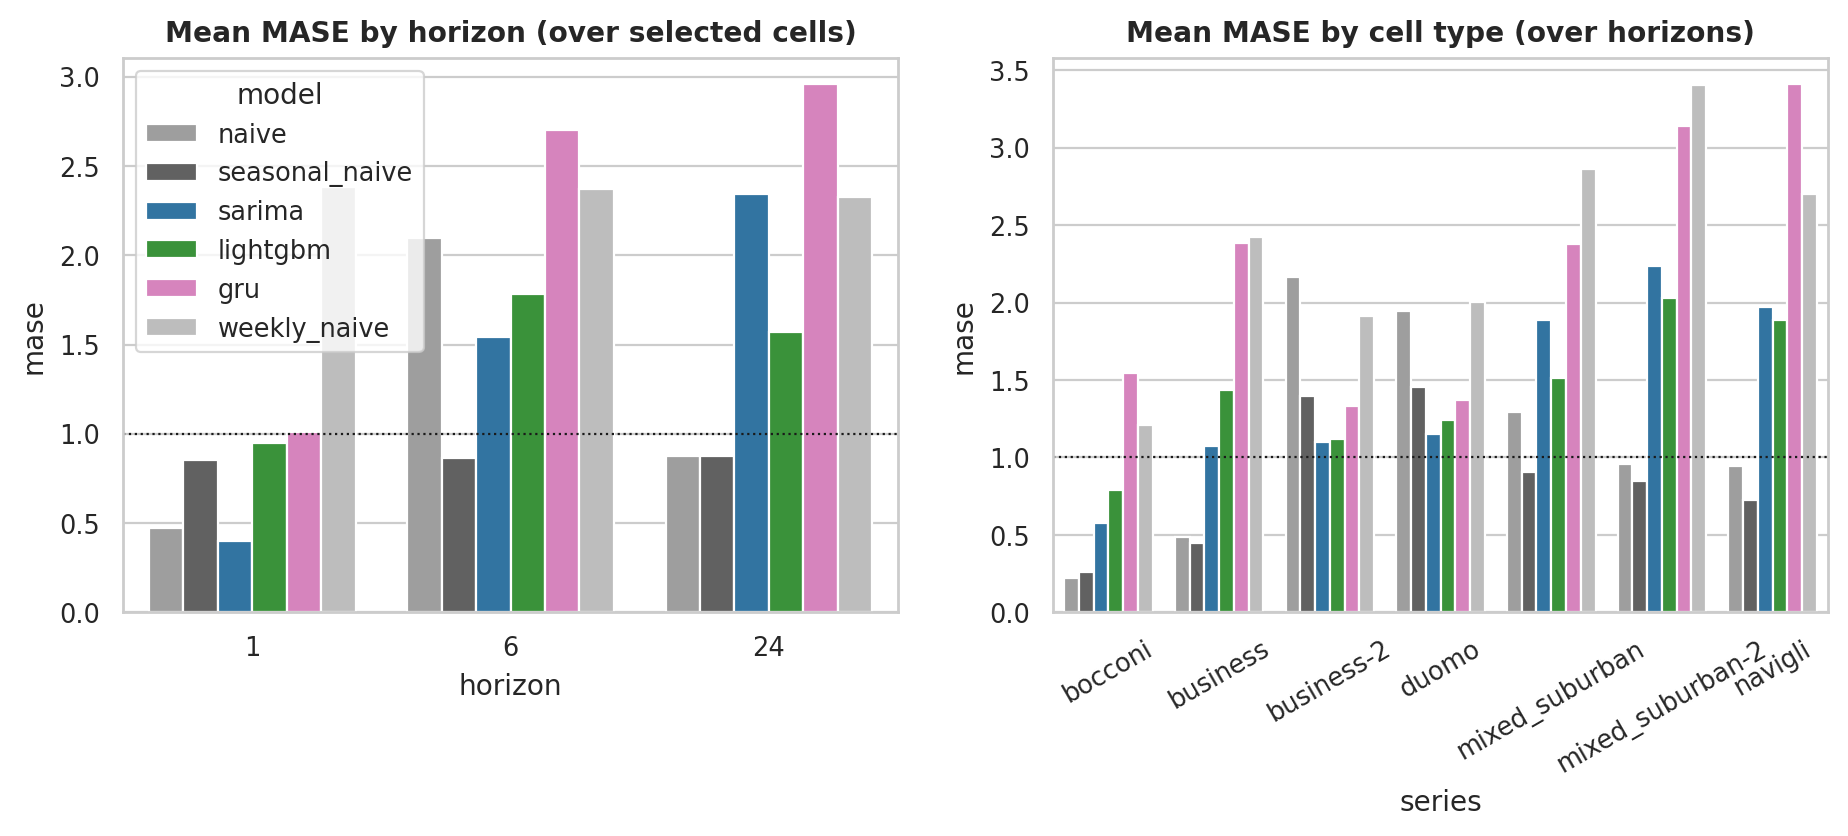

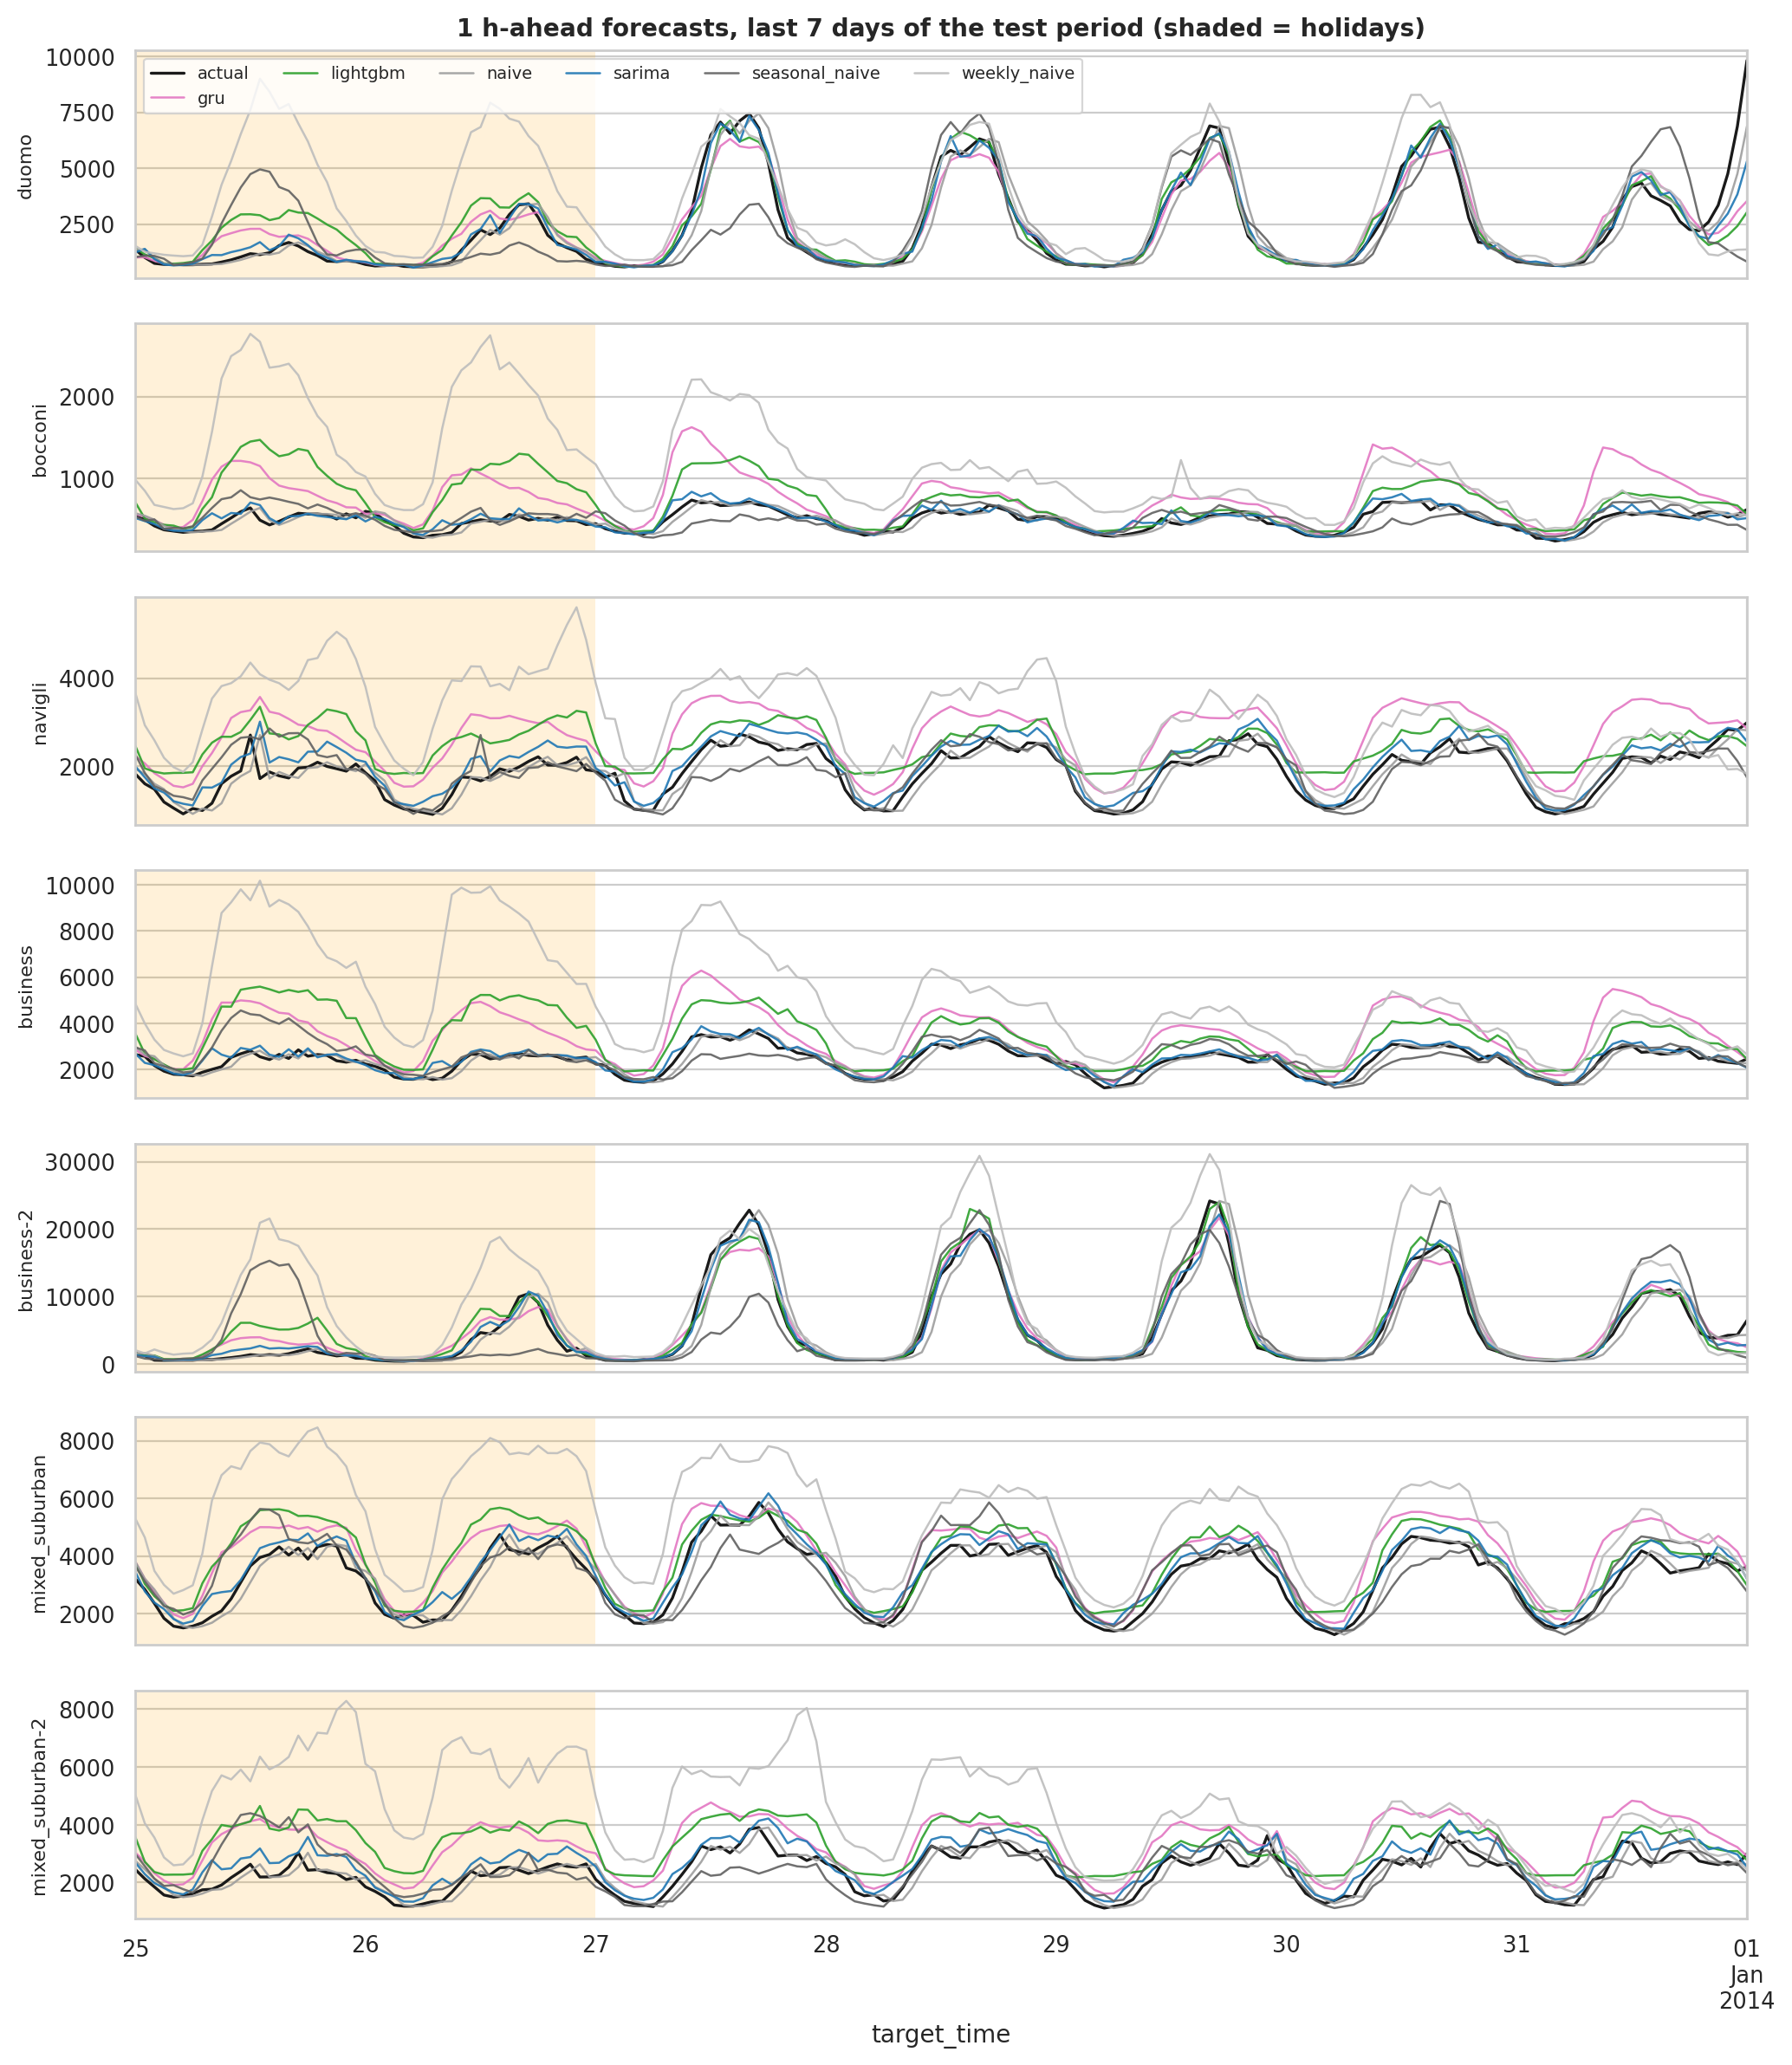

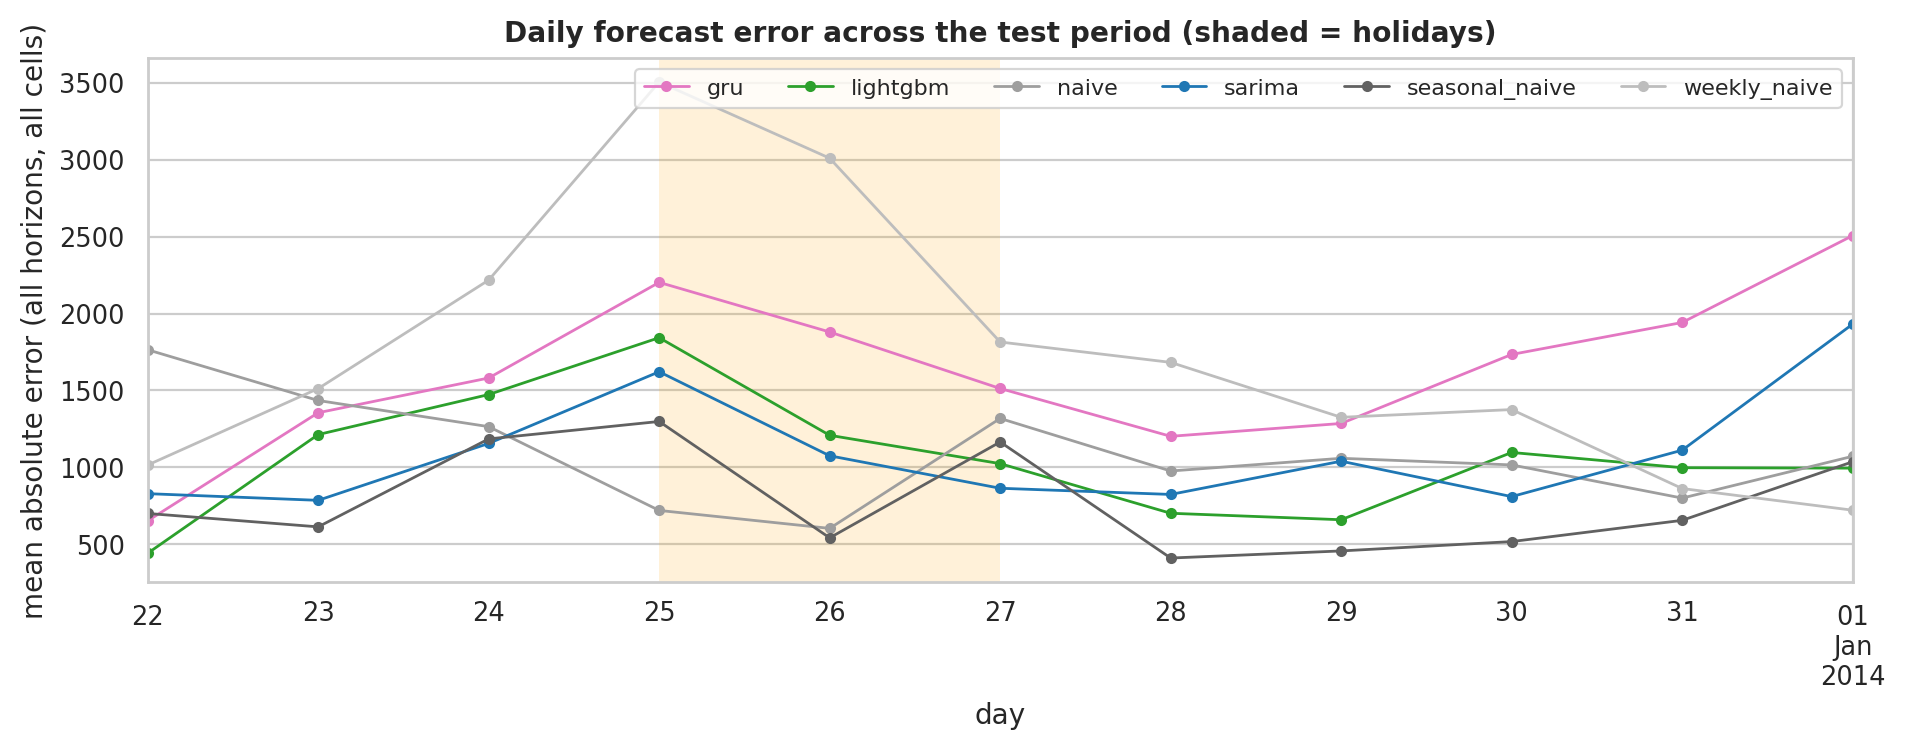

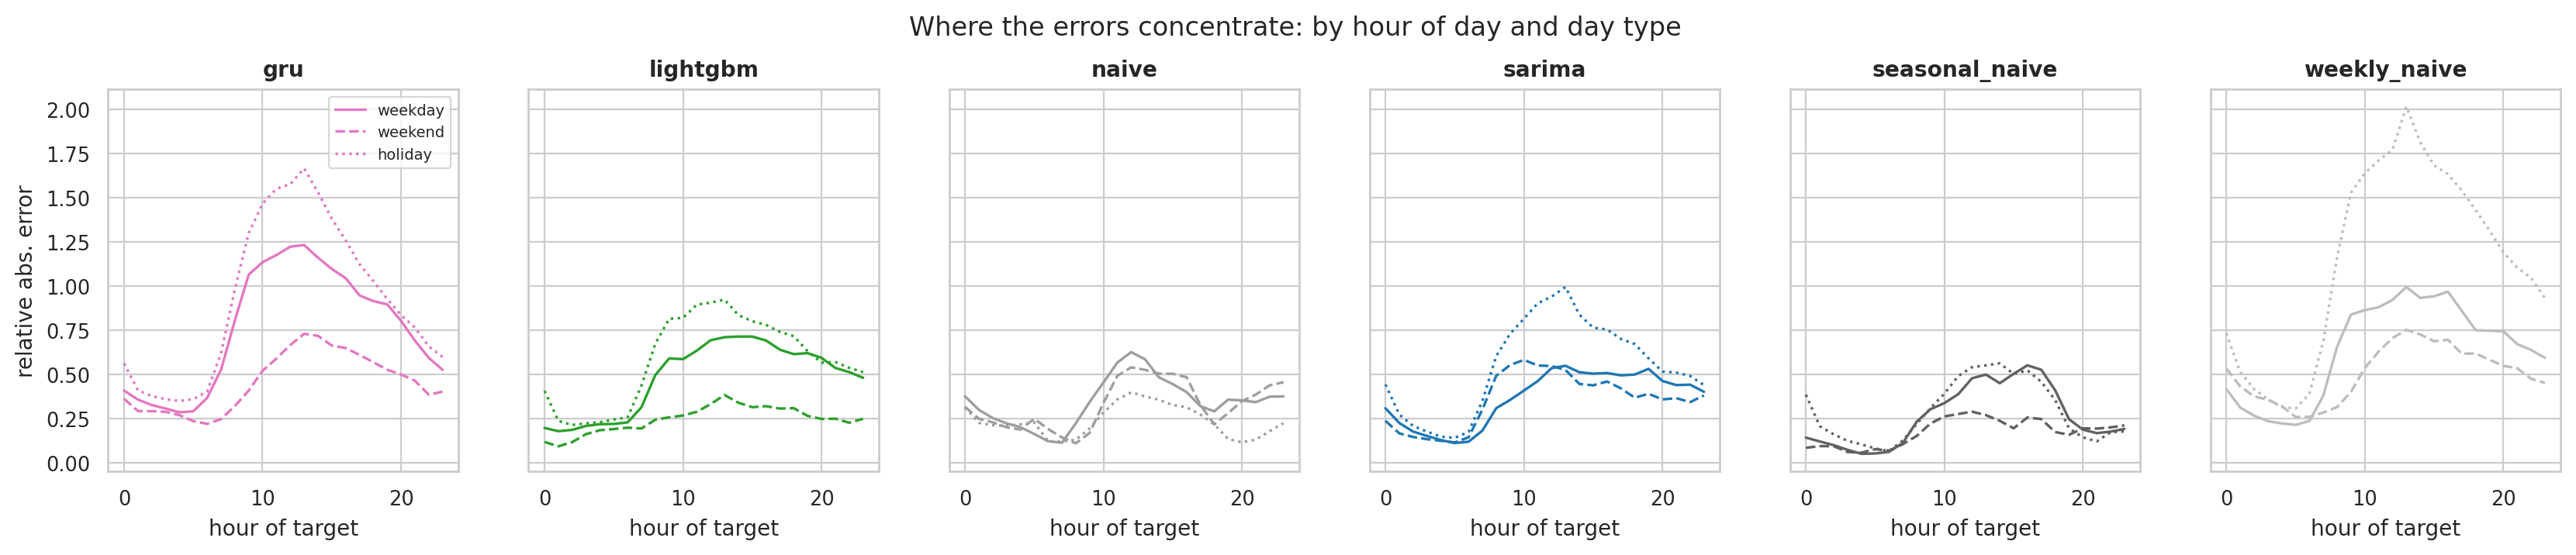

In [9]:
for f in ["results_mase_by_horizon_and_cell", "results_forecasts_h1", "failure_daily_error", "failure_hour_daytype"]:
    display(Image(f"reports/figures/{f}.png", width=900))

## Stage 7: report assets

No number in the report is typed by hand. `07_report_assets.py` turns the CSVs into LaTeX tables and `\newcommand` macros under `report/generated/`.

The last cell zips `reports/`, `experiments/` and those generated files. Kaggle has no LaTeX, so I unpack them in my local clone and build the PDF there.

In [10]:
run("scripts/07_report_assets.py")
!zip -qr results_bundle.zip reports experiments report/generated
print("download results_bundle.zip, unpack it in the local clone, then run report/build.sh")

> /usr/bin/python3 scripts/07_report_assets.py --config config/kaggle.yaml


INFO wrote 73 macros and tables to /kaggle/working/Time-Series-Forecasting/report/generated


download results_bundle.zip, unpack it in the local clone, then run report/build.sh
